In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA, UFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

In [2]:
# Load data
with open('./data/players_shots_density.pickle', 'rb') as f:
    players_shots_density = pickle.load(f)
with open('./data/player_position.pickle', 'rb') as f:
    players_position = pickle.load(f)

# Load UFPCA results
with open('./data/UFPCA.pickle', 'rb') as f:
    ufpca = pickle.load(f)
with open('./data/scores_ufpca.pickle', 'rb') as f:
    scores = pickle.load(f)
with open('./data/UFPCA_reconstruction.pickle', 'rb') as f:
    fdata_reconstruction = pickle.load(f)

In [3]:
# Get parameters
n_obs = ufpca.eigenfunctions.n_obs
pct = 100 * ufpca.eigenvalues / np.sum(ufpca.eigenvalues)

In [4]:
# Reshape scores
scores = pd.DataFrame(scores)
scores.insert(loc=0, column='PLAYER_ID', value=players_shots_density.PLAYER_ID.values)
scores.insert(loc=0, column='PLAYER_NAME', value=players_shots_density.PLAYER_NAME.values)
scores = scores.join(players_position.set_index('PLAYER_ID'), how='left', on='PLAYER_ID', rsuffix='_')

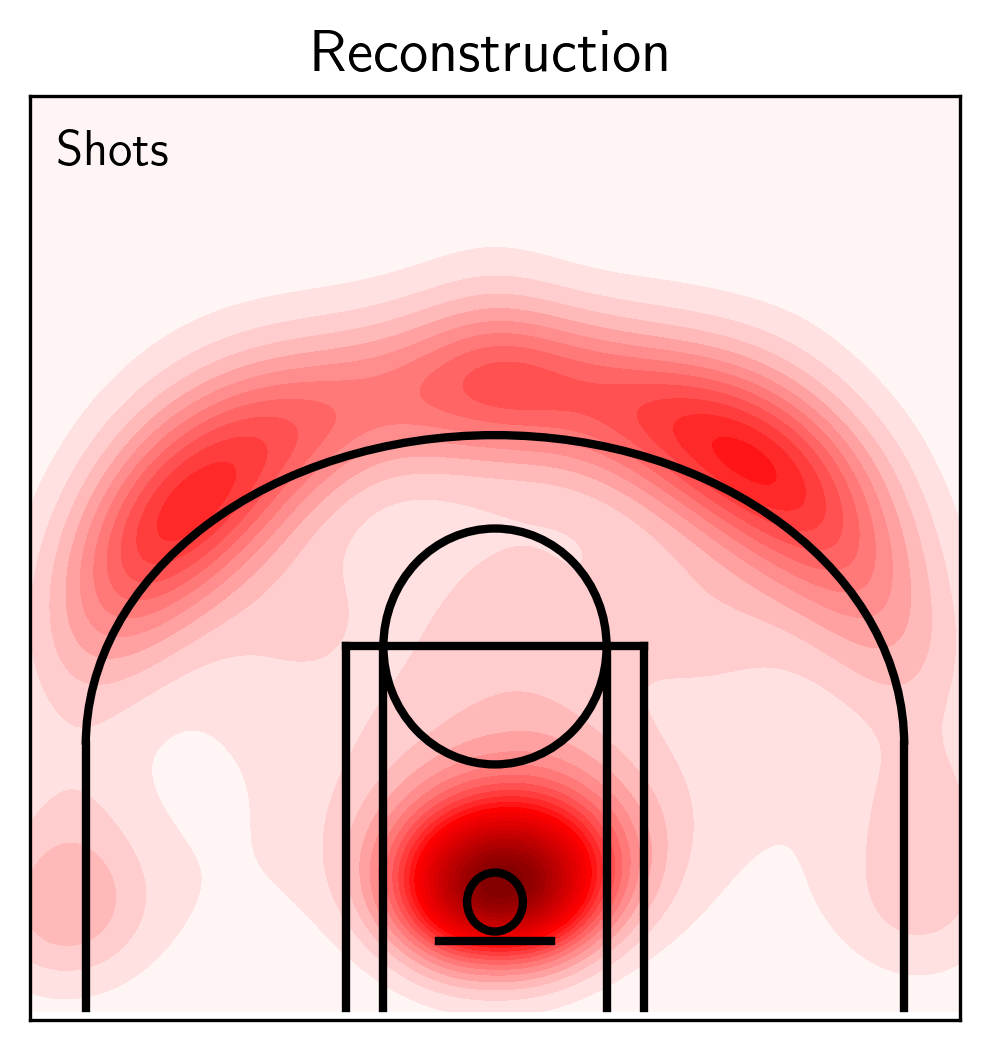

In [5]:
# Reconstruction for Stephen Curry
name = 'Stephen Curry'

# Reconstruction
fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 4),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax = ShotCharts.shots_chart_reconstruction(
    ax, players_shots_density, fdata_reconstruction, name, 'Shots', False
)
ax.set_title(f"Reconstruction", fontsize='x-large')

plt.savefig('./figures/univ_curry_reconstruction.eps', transparent=True, format='eps')
plt.show()

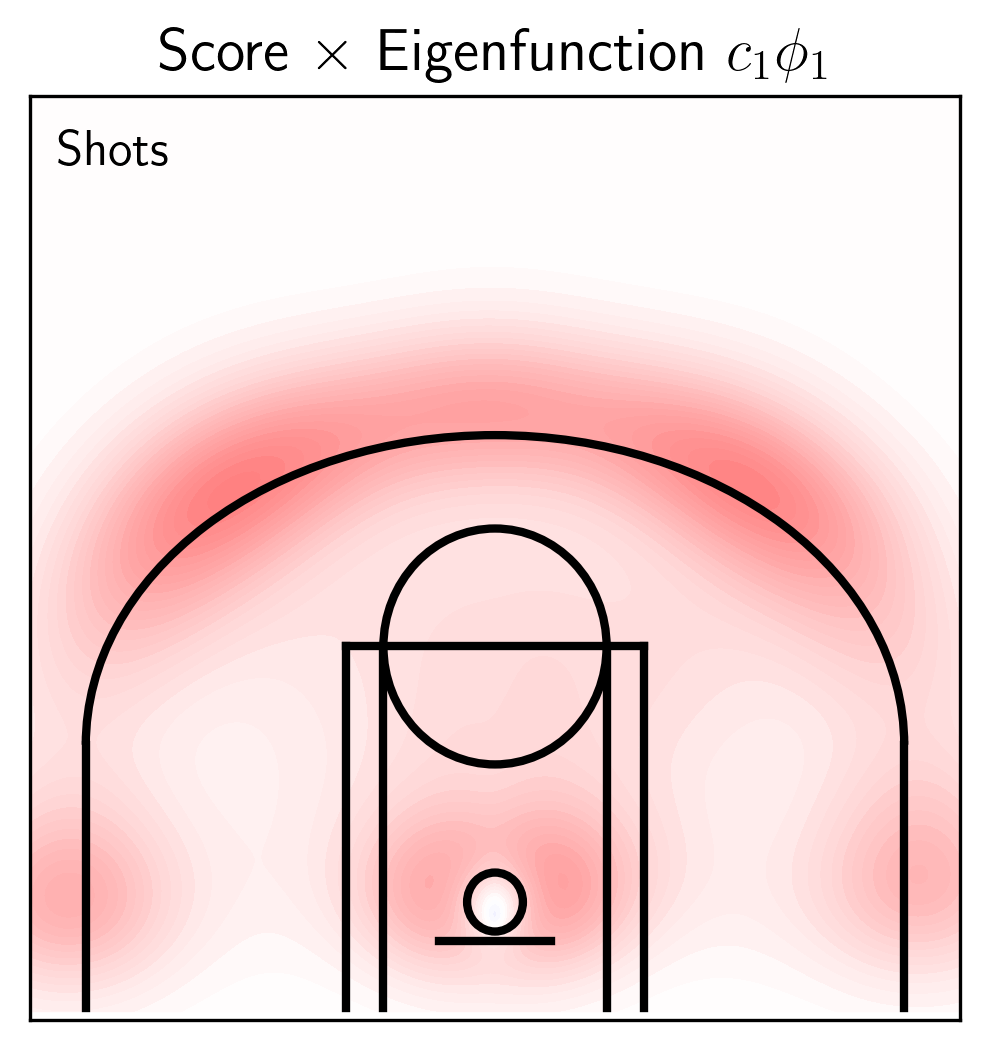

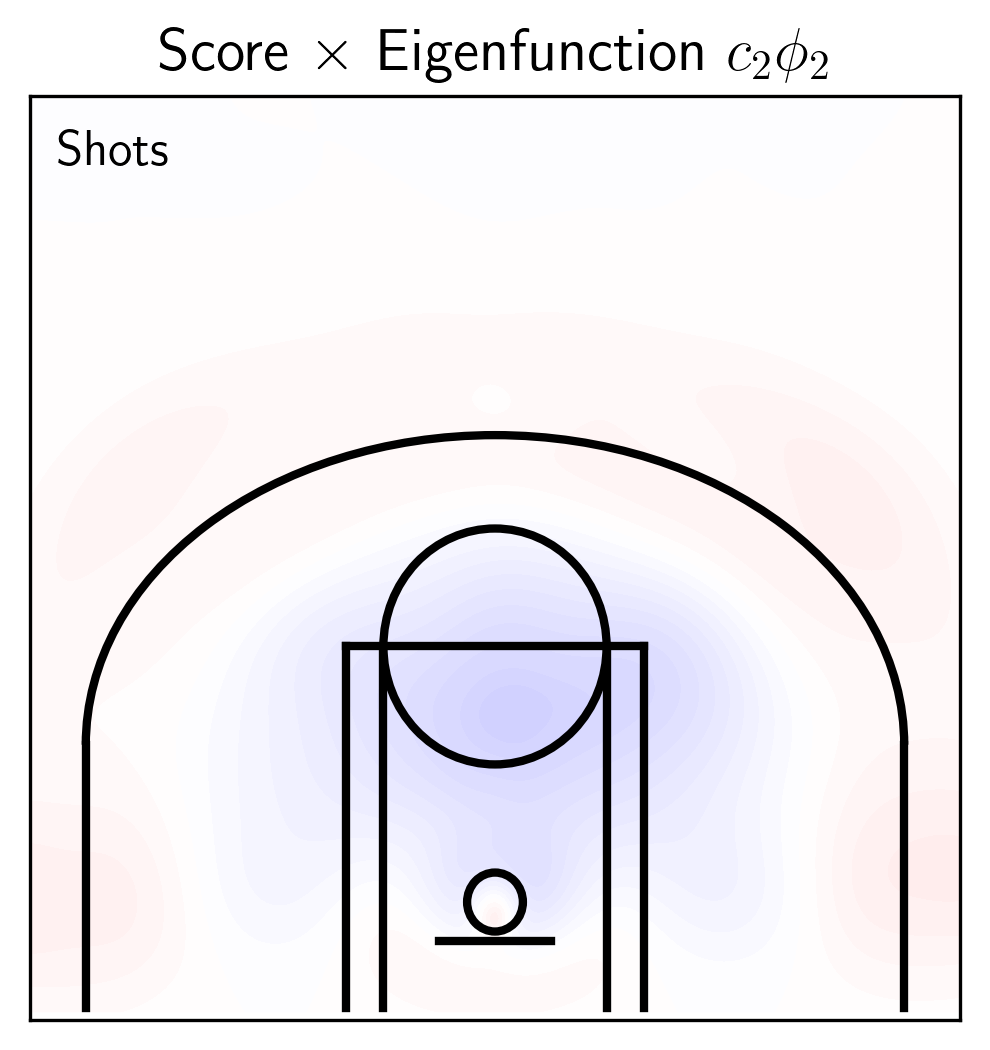

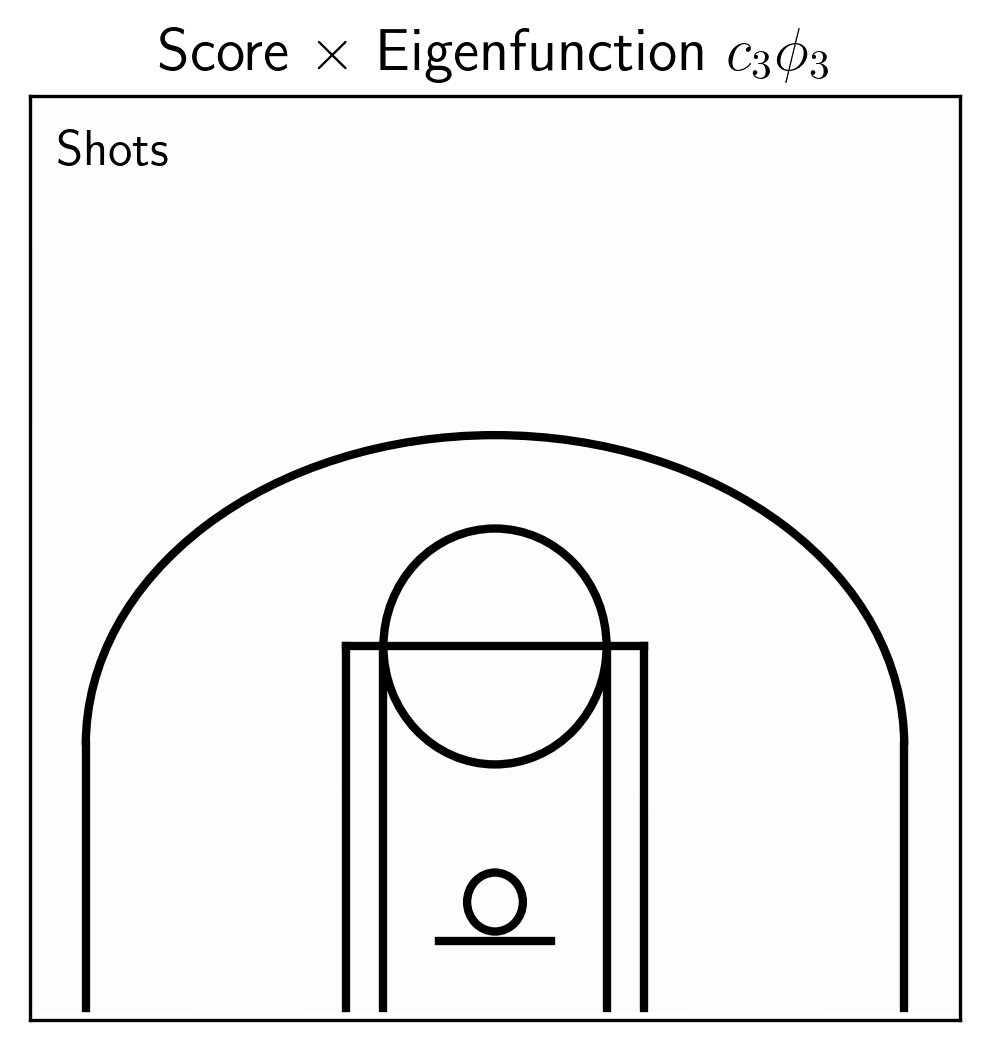

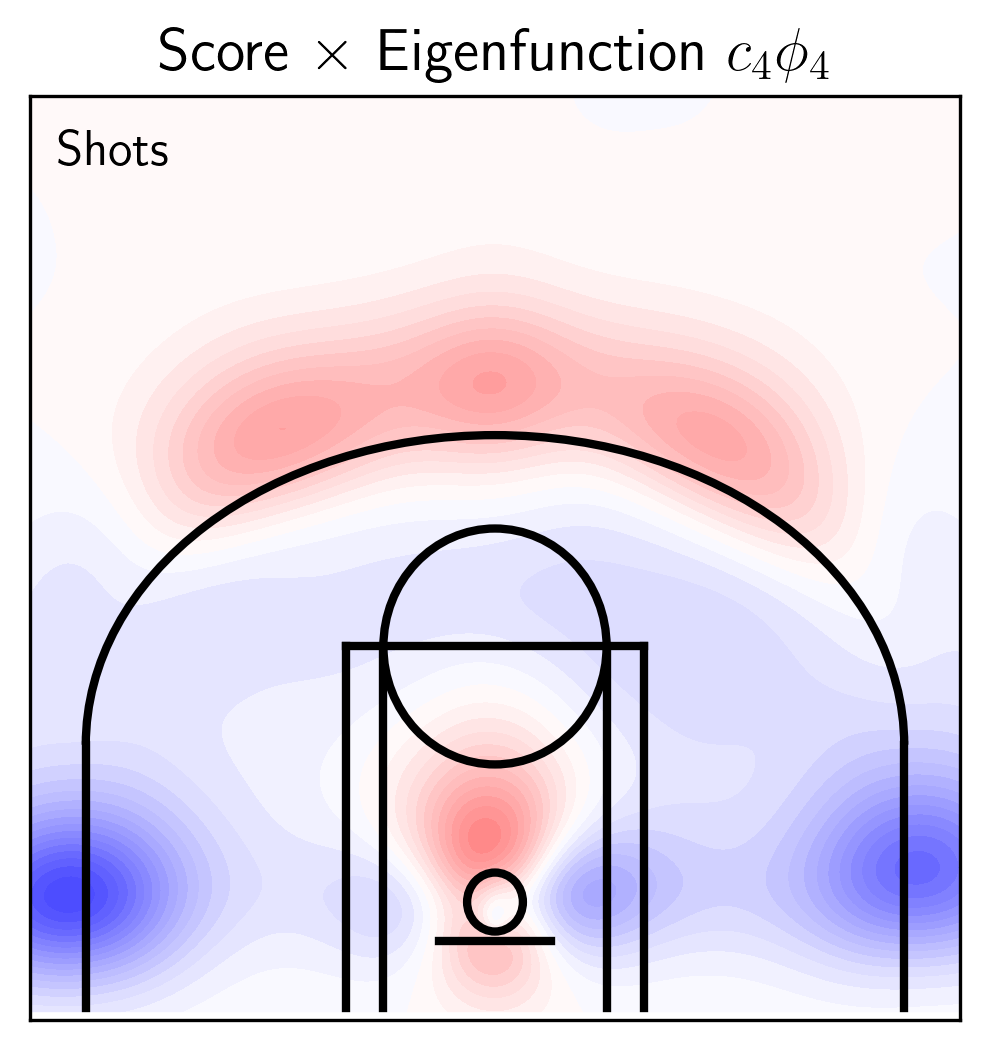

In [6]:
# Decomposition
name = 'Stephen Curry'

for idx in range(4):
    fig, ax = plt.subplots(
        1, 1,
        figsize=(4, 4),
        facecolor='white',
        edgecolor='black',
        dpi=300
    )
    maxi = np.max(np.abs(
        np.einsum('i, jk -> ijk', scores[idx].values, ufpca.eigenfunctions[idx].values.squeeze())
    ))

    ax = ShotCharts.shots_decomposition_chart(
        ax, ufpca, scores, idx, 0, name, 'Shots', maxi
    )
    ax.set_title(f"Score $\\times$ Eigenfunction $c_{{{idx + 1}}}\phi_{{{idx + 1}}}$", fontsize='x-large')

    # plt.savefig(f'./figures/curry_eigenfunction_{idx + 1}.eps', transparent=True, format='eps')
    # plt.show()
